# Final Analysis Visuals

This notebook collects the report-ready visual plan for **Books That Evolve**. It uses the reproducible pipeline outputs and builds seven final views:

1. Theme popularity share over time
2. Era timeline / year breaks
3. Theme mix by era
4. Top books by era
5. Blockbuster effect comparison
6. Keyword evolution and era vocabulary table
7. Books by year

The notebook also saves report-ready images and tables to `outputs/report/`.

In [9]:
from __future__ import annotations

import json
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "scripts"))

from plot_style import PALETTE, TEXT_COLOR, apply_light_academia_style, color_map

apply_light_academia_style()

REPORT_DIR = ROOT / "outputs" / "report"
CHART_DIR = REPORT_DIR / "charts"
TABLE_DIR = REPORT_DIR / "tables"
CHART_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

ERA_BREAKS = [2009, 2014, 2019]
ERA_ORDER = ["1997-2008", "2009-2013", "2014-2018", "2019-2021"]

THEME_ORDER = [
    "Middle Grade Fantasy",
    "Mythology Adventure",
    "Paranormal / Supernatural",
    "Paranormal Romance",
    "Dystopian / Post-Apocalyptic",
    "Science Fiction",
    "Epic / High Fantasy",
    "Romantasy",
]

TRACKED_KEYWORDS = [
    "magic", "wizard", "dragon", "kingdom", "realm", "court", "fae", "vampire",
    "werewolf", "angel", "demon", "ghost", "academy", "school", "dystopia",
    "rebellion", "district", "apocalypse", "space", "alien", "robot", "love",
    "mate", "curse", "prophecy",
]

def assign_era(year: int) -> str:
    if year < 2009:
        return "1997-2008"
    if year < 2014:
        return "2009-2013"
    if year < 2019:
        return "2014-2018"
    return "2019-2021"

def savefig(fig: plt.Figure, filename: str) -> None:
    fig.savefig(CHART_DIR / filename, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())

def pct_axis(ax):
    ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")

def clean_theme_tags(value: object) -> str:
    try:
        parsed = json.loads(str(value))
    except json.JSONDecodeError:
        return str(value)
    return ", ".join(tag.replace("_", " ").title() for tag in parsed)


In [10]:
books = pd.read_csv(ROOT / "data" / "processed_books.csv", low_memory=False)
annual_theme = pd.read_csv(ROOT / "outputs" / "tables" / "annual_theme_popularity_share.csv")
era_summary = pd.read_csv(ROOT / "outputs" / "tables" / "data_driven_era_summary.csv")
top_books = pd.read_csv(ROOT / "outputs" / "tables" / "top_books_by_data_driven_era.csv")
era_top_themes = pd.read_csv(ROOT / "outputs" / "exploratory" / "tables" / "era_top_themes.csv")
keyword_year = pd.read_csv(ROOT / "outputs" / "exploratory" / "tables" / "keyword_trends_by_year.csv")
keyword_era = pd.read_csv(ROOT / "outputs" / "exploratory" / "tables" / "keyword_trends_by_era.csv")

books["data_driven_era"] = books["first_publish_year"].astype(int).map(assign_era)
books["numRatings_clean"] = pd.to_numeric(books["numRatings_clean"], errors="coerce").fillna(0)
books["bbeVotes_clean"] = pd.to_numeric(books["bbeVotes_clean"], errors="coerce").fillna(0)
books["popularity_score"] = pd.to_numeric(books["popularity_score"], errors="coerce")

print(f"Books analyzed: {len(books):,}")
print(f"Year range: {books.first_publish_year.min()}-{books.first_publish_year.max()}")
print(f"Themes tracked: {annual_theme.theme_label.nunique()}")

Books analyzed: 6,552
Year range: 1997-2021
Themes tracked: 8


## 1. Theme Popularity Share Over Time

This is the core trend chart. It shows each theme's share of annual weighted popularity, with vertical guides marking the era breaks.

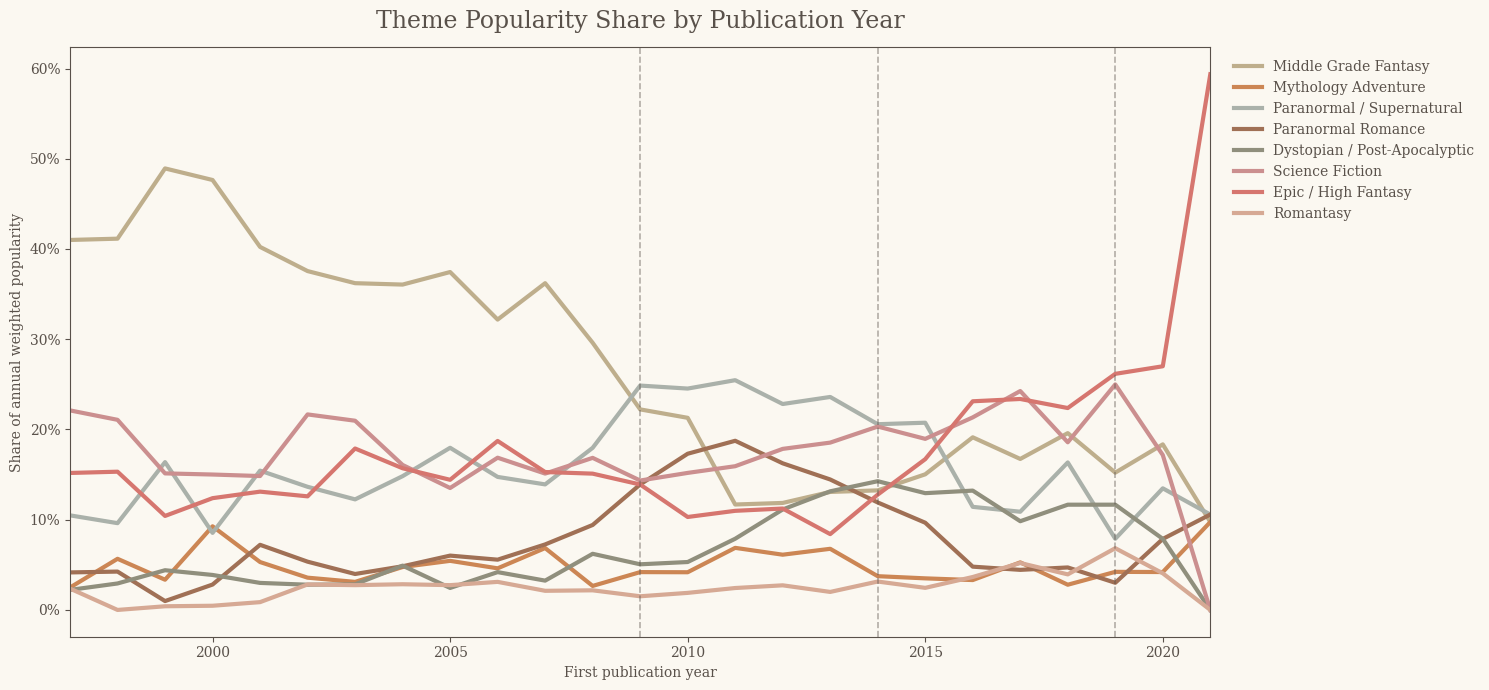

In [11]:
share_by_year = (
    annual_theme.pivot(index="first_publish_year", columns="theme_label", values="popularity_share")
    .fillna(0)
    .reindex(columns=THEME_ORDER)
)
theme_colors = color_map(THEME_ORDER)

fig, ax = plt.subplots(figsize=(15, 7))
for theme in THEME_ORDER:
    ax.plot(
        share_by_year.index,
        share_by_year[theme],
        label=theme,
        color=theme_colors[theme],
        linewidth=3.0,
    )
for break_year in ERA_BREAKS:
    ax.axvline(break_year, color=TEXT_COLOR, linestyle="--", linewidth=1.2, alpha=0.45)
ax.set_title("Theme Popularity Share by Publication Year", fontsize=17, pad=14)
ax.set_xlabel("First publication year")
ax.set_ylabel("Share of annual weighted popularity")
ax.set_xlim(share_by_year.index.min(), share_by_year.index.max())
pct_axis(ax)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
plt.tight_layout()
savefig(fig, "01_theme_popularity_share_over_time.png")
plt.show()

## 2. Data-Driven Era Boundaries

This chart shows the boundary method from the original theme-era analysis notebook. Annual theme shares are smoothed with a centered rolling window, then each year is scored by how much the full theme-share mix changes from the previous year. The selected era breaks mark years where the theme mix shifts sharply while keeping a minimum gap between eras.

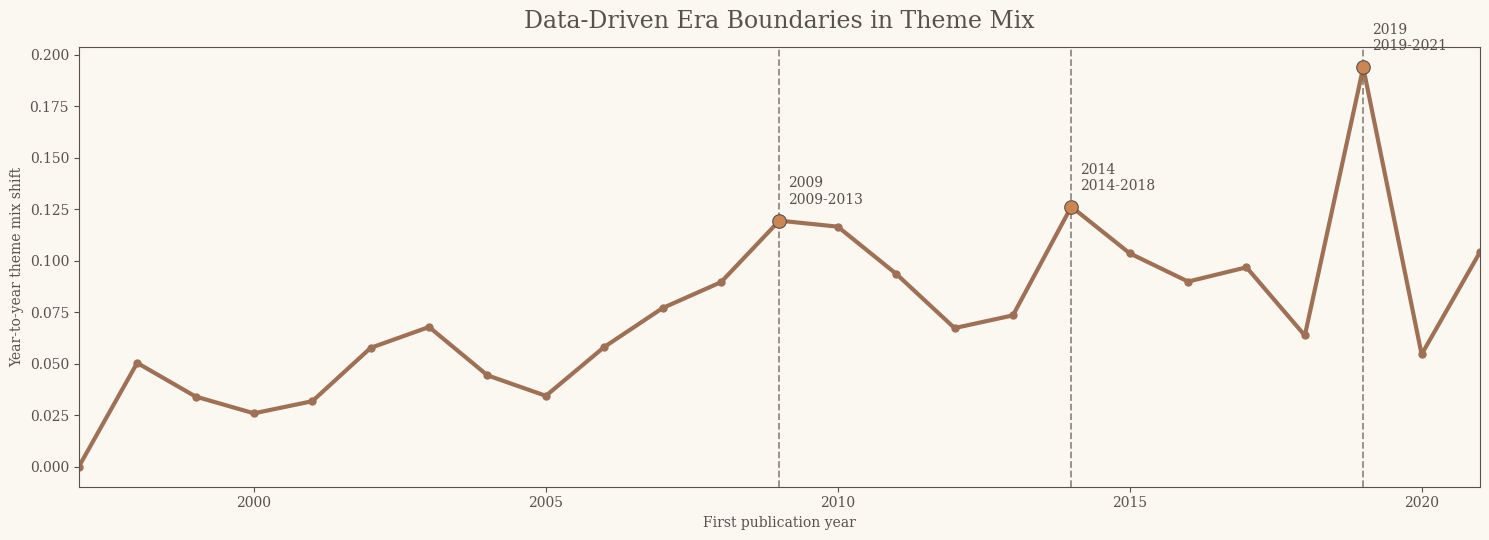

,break_year,theme_mix_shift,era_after_break
0,2009,0.119,2009-2013
1,2014,0.126,2014-2018
2,2019,0.194,2019-2021


In [12]:
smoothed_shares = share_by_year.rolling(window=5, center=True, min_periods=1).mean()
yearly_shift = smoothed_shares.diff().abs().sum(axis=1).rename("theme_mix_shift").dropna()
breakpoints = pd.DataFrame({"break_year": ERA_BREAKS}).merge(
    yearly_shift.rename("theme_mix_shift").reset_index().rename(columns={"first_publish_year": "break_year"}),
    on="break_year",
    how="left",
)
breakpoints["era_after_break"] = ["2009-2013", "2014-2018", "2019-2021"]
breakpoints.to_csv(TABLE_DIR / "data_driven_era_boundaries_report.csv", index=False)

fig, ax = plt.subplots(figsize=(15, 5.5))
ax.plot(
    yearly_shift.index,
    yearly_shift.values,
    color=PALETTE[3],
    linewidth=3,
    marker="o",
    markersize=5,
)
for row in breakpoints.itertuples(index=False):
    ax.axvline(row.break_year, color=TEXT_COLOR, linestyle="--", linewidth=1.3, alpha=0.65)
    ax.scatter(row.break_year, row.theme_mix_shift, s=95, color=PALETTE[1], edgecolor=TEXT_COLOR, linewidth=0.8, zorder=4)
    ax.text(
        row.break_year + 0.15,
        row.theme_mix_shift + yearly_shift.max() * 0.035,
        f"{row.break_year}\n{row.era_after_break}",
        ha="left",
        va="bottom",
        fontsize=10,
    )
ax.set_title("Data-Driven Era Boundaries in Theme Mix", fontsize=17, pad=14)
ax.set_xlabel("First publication year")
ax.set_ylabel("Year-to-year theme mix shift")
ax.set_xlim(share_by_year.index.min(), share_by_year.index.max())
plt.tight_layout()
savefig(fig, "02_data_driven_era_boundaries.png")
plt.show()

display(breakpoints.style.format({"theme_mix_shift": "{:.3f}"}))

## 3. Theme Mix by Era

The annual chart is good for movement; the stacked bar makes the era story easier to compare at a glance.

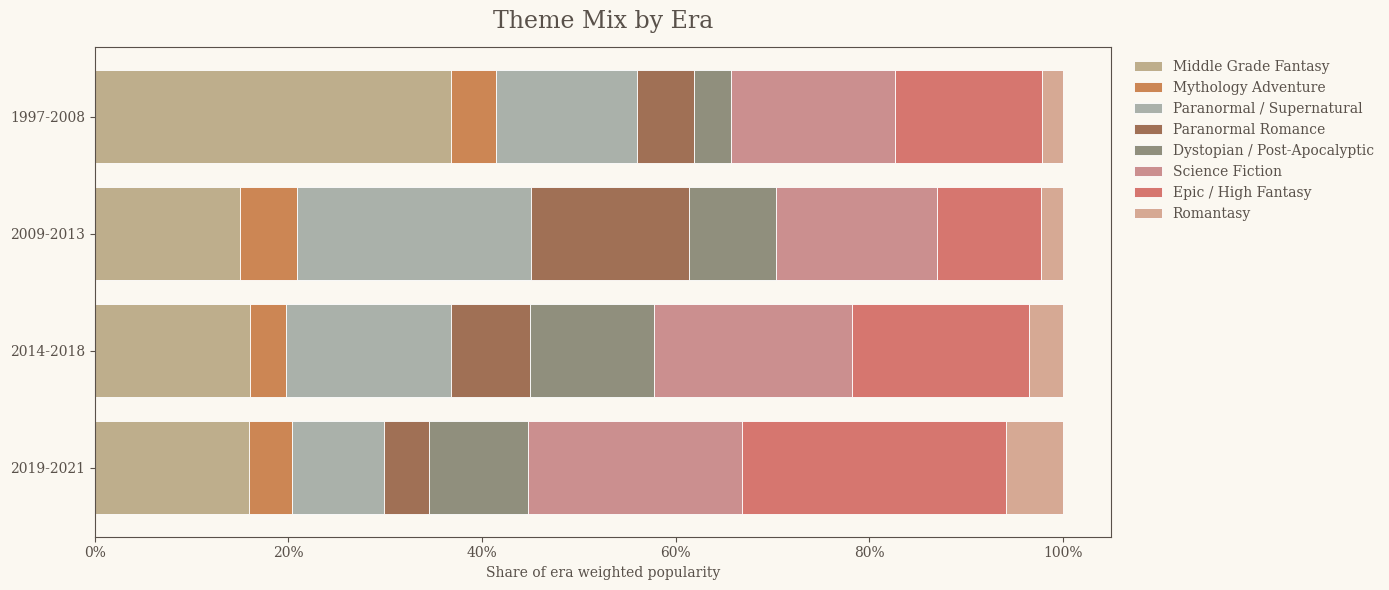

In [13]:
era_theme = era_top_themes.copy()
era_theme["data_driven_era"] = pd.Categorical(era_theme["data_driven_era"], ERA_ORDER, ordered=True)
era_mix = (
    era_theme.pivot(index="data_driven_era", columns="theme_label", values="popularity_share")
    .fillna(0)
    .reindex(index=ERA_ORDER, columns=THEME_ORDER)
)

fig, ax = plt.subplots(figsize=(14, 6))
left = np.zeros(len(era_mix))
y = np.arange(len(era_mix))
for theme in THEME_ORDER:
    values = era_mix[theme].values
    ax.barh(y, values, left=left, label=theme, color=theme_colors[theme], edgecolor="white", linewidth=0.6)
    left += values
ax.set_yticks(y)
ax.set_yticklabels(era_mix.index)
ax.invert_yaxis()
ax.set_xlabel("Share of era weighted popularity")
ax.set_title("Theme Mix by Era", fontsize=17, pad=14)
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
plt.tight_layout()
savefig(fig, "03_theme_mix_by_era.png")
plt.show()

## 4. Top Books by Era

This table connects the theme patterns to recognizable books. It is intentionally a table rather than a chart because titles and authors carry the evidence.

In [14]:
top_books_display = top_books.copy()
top_books_display["theme_tags"] = top_books_display["theme_tags"].map(clean_theme_tags)
top_books_display = top_books_display[[
    "data_driven_era", "first_publish_year", "title_clean", "primary_author", "popularity_score", "theme_tags"
]].rename(columns={
    "data_driven_era": "Era",
    "first_publish_year": "Year",
    "title_clean": "Title",
    "primary_author": "Author",
    "popularity_score": "Popularity score",
    "theme_tags": "Themes",
})
top_books_display["Popularity score"] = top_books_display["Popularity score"].round(2)
top_books_display.to_csv(TABLE_DIR / "top_books_by_era_report.csv", index=False)
display(top_books_display)

,Era,Year,Title,Author,Popularity score,Themes
0,1997-2008,2008,The Hunger Games,Suzanne Collins,3.92,"Dystopian Post Apocalyptic, Science Fiction"
1,1997-2008,2003,Harry Potter and the Order of the Phoenix,J.K. Rowling,3.83,Middle Grade Fantasy
2,1997-2008,1997,Harry Potter and the Sorcerer's Stone,J.K. Rowling,3.83,Middle Grade Fantasy
3,1997-2008,2007,Harry Potter and the Deathly Hallows,J.K. Rowling,3.62,Middle Grade Fantasy
4,1997-2008,1999,Harry Potter and the Prisoner of Azkaban,J.K. Rowling,3.51,Middle Grade Fantasy
5,1997-2008,2000,Harry Potter and the Goblet of Fire,J.K. Rowling,3.42,Middle Grade Fantasy
6,1997-2008,2005,Harry Potter and the Half-Blood Prince,J.K. Rowling,3.40,Middle Grade Fantasy
7,1997-2008,2005,The Lightning Thief,Rick Riordan,3.25,"Middle Grade Fantasy, Mythology Adventure"
8,2009-2013,2011,Divergent,Veronica Roth,3.33,"Dystopian Post Apocalyptic, Science Fiction"
9,2009-2013,2009,Catching Fire,Suzanne Collins,2.95,"Dystopian Post Apocalyptic, Science Fiction"


## 5. Blockbuster Effect / Visibility Concentration

Instead of treating this as a simple scenario comparison, this section tests concentration directly.

Hypothesis: a small number of highly visible books, many of them franchise/blockbuster titles, account for a disproportionate share of Goodreads visibility.

The chart below is a cumulative visibility curve: books are ranked by `numRatings_clean` within each era, then the curve shows how much of the era's total ratings are captured by the top share of books. A steeper curve means more concentration.

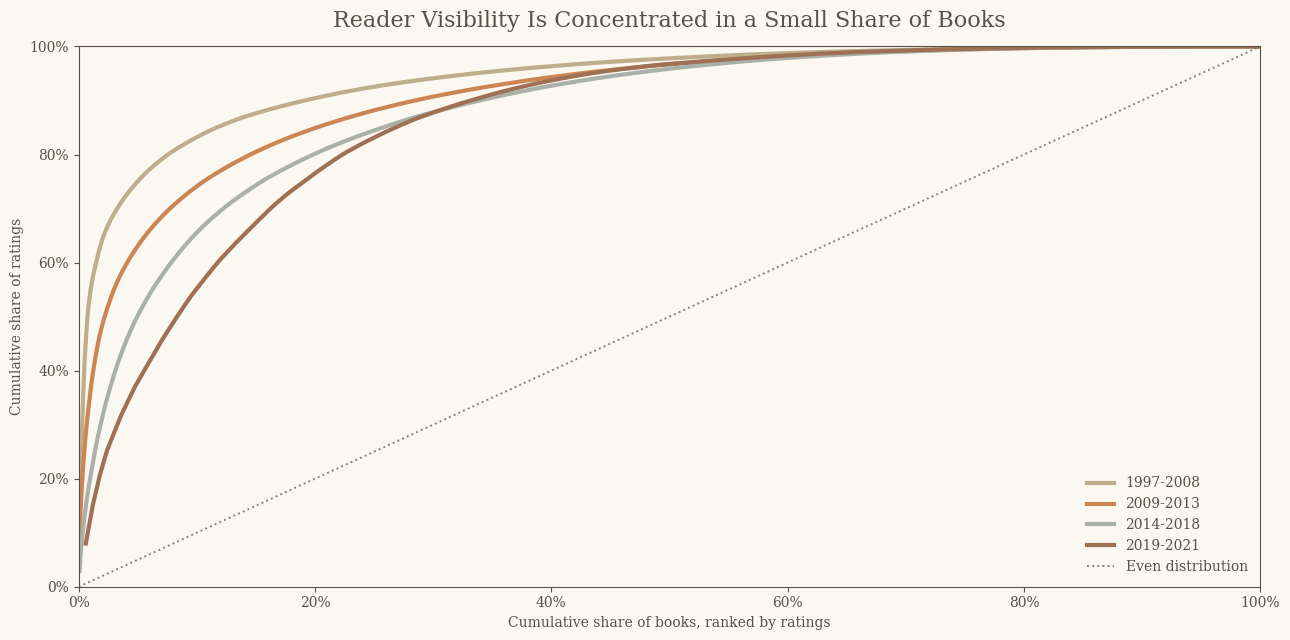

,data_driven_era,book_count,blockbuster_book_share,blockbuster_rating_share,top_1pct_rating_share,top_5pct_rating_share,top_1pct_blockbuster_books,top_5pct_blockbuster_books
0,1997-2008,1983,3.6%,63.7%,55.1%,75.2%,19,43
1,2009-2013,2897,4.1%,46.4%,36.4%,63.1%,26,53
2,2014-2018,1504,6.0%,32.4%,21.3%,50.4%,12,29
3,2019-2021,168,4.8%,14.7%,15.1%,39.3%,1,2


In [15]:
concentration_rows = []
summary_rows = []
for era, group in books.groupby("data_driven_era", sort=False):
    ranked = group.sort_values("numRatings_clean", ascending=False).reset_index(drop=True).copy()
    ranked["book_share"] = (np.arange(len(ranked)) + 1) / len(ranked)
    ranked["rating_share"] = ranked["numRatings_clean"].cumsum() / ranked["numRatings_clean"].sum()
    ranked["bbe_vote_share"] = ranked["bbeVotes_clean"].cumsum() / ranked["bbeVotes_clean"].sum()
    ranked["data_driven_era"] = era
    concentration_rows.append(ranked[["data_driven_era", "book_share", "rating_share", "bbe_vote_share", "series_flag", "title_clean", "primary_author"]])

    top_1pct_n = max(1, int(np.ceil(len(ranked) * 0.01)))
    top_5pct_n = max(1, int(np.ceil(len(ranked) * 0.05)))
    top_1pct = ranked.head(top_1pct_n)
    top_5pct = ranked.head(top_5pct_n)
    is_blockbuster = group["series_flag"].eq("blockbuster_franchise")
    summary_rows.append({
        "data_driven_era": era,
        "book_count": len(group),
        "blockbuster_book_share": is_blockbuster.mean(),
        "blockbuster_rating_share": group.loc[is_blockbuster, "numRatings_clean"].sum() / group["numRatings_clean"].sum(),
        "top_1pct_rating_share": top_1pct["numRatings_clean"].sum() / group["numRatings_clean"].sum(),
        "top_5pct_rating_share": top_5pct["numRatings_clean"].sum() / group["numRatings_clean"].sum(),
        "top_1pct_blockbuster_books": int(top_1pct["series_flag"].eq("blockbuster_franchise").sum()),
        "top_5pct_blockbuster_books": int(top_5pct["series_flag"].eq("blockbuster_franchise").sum()),
    })

visibility_concentration = pd.concat(concentration_rows, ignore_index=True)
visibility_summary = pd.DataFrame(summary_rows)
visibility_concentration.to_csv(TABLE_DIR / "visibility_concentration_curve.csv", index=False)
visibility_summary.to_csv(TABLE_DIR / "blockbuster_visibility_summary_by_era.csv", index=False)

fig, ax = plt.subplots(figsize=(13, 6.5))
era_colors = color_map(ERA_ORDER)
for era in ERA_ORDER:
    group = visibility_concentration.loc[visibility_concentration["data_driven_era"].eq(era)]
    ax.plot(group["book_share"], group["rating_share"], color=era_colors[era], linewidth=3, label=era)
ax.plot([0, 1], [0, 1], color=TEXT_COLOR, linestyle=":", linewidth=1.4, alpha=0.7, label="Even distribution")
ax.set_title("Reader Visibility Is Concentrated in a Small Share of Books", fontsize=16, pad=14)
ax.set_xlabel("Cumulative share of books, ranked by ratings")
ax.set_ylabel("Cumulative share of ratings")
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
savefig(fig, "04_visibility_concentration_curve.png")
plt.show()

display(visibility_summary.style.format({
    "blockbuster_book_share": "{:.1%}",
    "blockbuster_rating_share": "{:.1%}",
    "top_1pct_rating_share": "{:.1%}",
    "top_5pct_rating_share": "{:.1%}",
}))

## 6. Keyword Evolution

The original multi-line keyword chart was too crowded. This version uses a heatmap: rows are tracked keywords, columns are eras, and color shows each keyword's share within that era's tracked keyword weight. The table below summarizes words that are newly prominent, remain prominent, or drop out of the top tracked set.

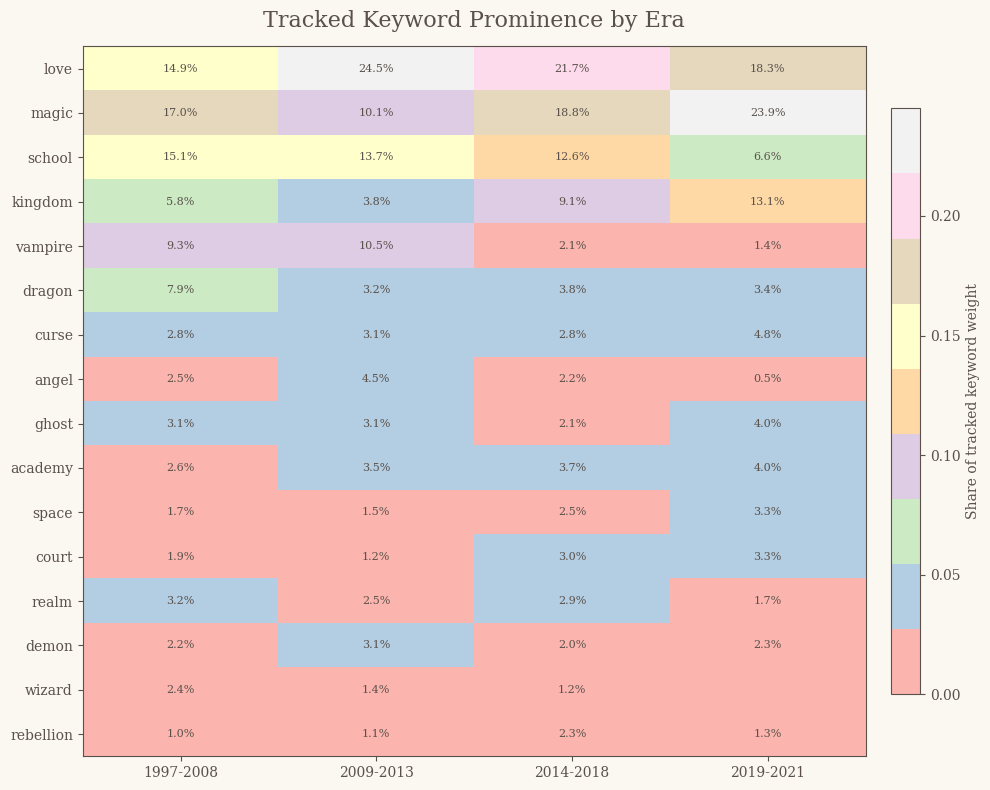

,era,new_or_newly_prominent,remained_prominent,dropped_from_previous,top_tracked_keywords
0,1997-2008,"magic, school, love, vampire, dragon, kingdom,...",-,-,"magic, school, love, vampire, dragon, kingdom,..."
1,2009-2013,"angel, academy","love, school, vampire, magic, kingdom, dragon","realm, ghost","love, school, vampire, magic, angel, kingdom, ..."
2,2014-2018,"court, realm","love, magic, school, kingdom, dragon, academy","vampire, angel","love, magic, school, kingdom, dragon, academy,..."
3,2019-2021,"curse, ghost","magic, love, kingdom, school, academy, dragon","court, realm","magic, love, kingdom, school, curse, ghost, ac..."


In [20]:
keyword_focus = keyword_era.loc[keyword_era["keyword"].isin(TRACKED_KEYWORDS)].copy()
era_totals = (
    keyword_focus.groupby("data_driven_era", as_index=False)["weighted_keyword_count"]
    .sum()
    .rename(columns={"weighted_keyword_count": "era_tracked_keyword_weight"})
)
keyword_focus = keyword_focus.merge(era_totals, on="data_driven_era", how="left")
keyword_focus["keyword_share"] = keyword_focus["weighted_keyword_count"] / keyword_focus["era_tracked_keyword_weight"]

keyword_heatmap = (
    keyword_focus.pivot(index="keyword", columns="data_driven_era", values="keyword_share")
    .fillna(0)
    .reindex(columns=ERA_ORDER)
)
keyword_heatmap = keyword_heatmap.loc[keyword_heatmap.max(axis=1).sort_values(ascending=False).head(16).index]
keyword_heatmap.to_csv(TABLE_DIR / "keyword_share_heatmap_by_era.csv")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(keyword_heatmap.values, aspect="auto", cmap="Pastel1")
ax.set_xticks(np.arange(len(keyword_heatmap.columns)))
ax.set_xticklabels(keyword_heatmap.columns)
ax.set_yticks(np.arange(len(keyword_heatmap.index)))
ax.set_yticklabels(keyword_heatmap.index)
ax.set_title("Tracked Keyword Prominence by Era", fontsize=16, pad=14)
for i in range(keyword_heatmap.shape[0]):
    for j in range(keyword_heatmap.shape[1]):
        value = keyword_heatmap.iloc[i, j]
        ax.text(j, i, f"{value:.1%}" if value > 0 else "", ha="center", va="center", fontsize=8, color=TEXT_COLOR)
fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03, label="Share of tracked keyword weight")
plt.tight_layout()
savefig(fig, "05_keyword_prominence_heatmap.png")
plt.show()

era_keyword_top = {}
for era in ERA_ORDER:
    top = (
        keyword_focus.loc[keyword_focus["data_driven_era"].eq(era)]
        .sort_values("weighted_keyword_count", ascending=False)
        .head(8)["keyword"]
        .tolist()
    )
    era_keyword_top[era] = top

transition_rows = []
previous = set()
for era in ERA_ORDER:
    current = set(era_keyword_top[era])
    previous_list = era_keyword_top.get(ERA_ORDER[ERA_ORDER.index(era)-1], []) if previous else []
    transition_rows.append({
        "era": era,
        "new_or_newly_prominent": ", ".join([word for word in era_keyword_top[era] if word not in previous]) or "-",
        "remained_prominent": ", ".join([word for word in era_keyword_top[era] if word in previous]) or "-",
        "dropped_from_previous": ", ".join([word for word in previous_list if word not in current]) or "-",
        "top_tracked_keywords": ", ".join(era_keyword_top[era]),
    })
    previous = current
keyword_transition = pd.DataFrame(transition_rows)
keyword_transition.to_csv(TABLE_DIR / "keyword_transition_by_era.csv", index=False)
display(keyword_transition)

## 7. Books by Year

This is a context chart rather than a findings chart. It shows how many scoped books are available per publication year, which matters when interpreting the shorter 2019-2021 era.

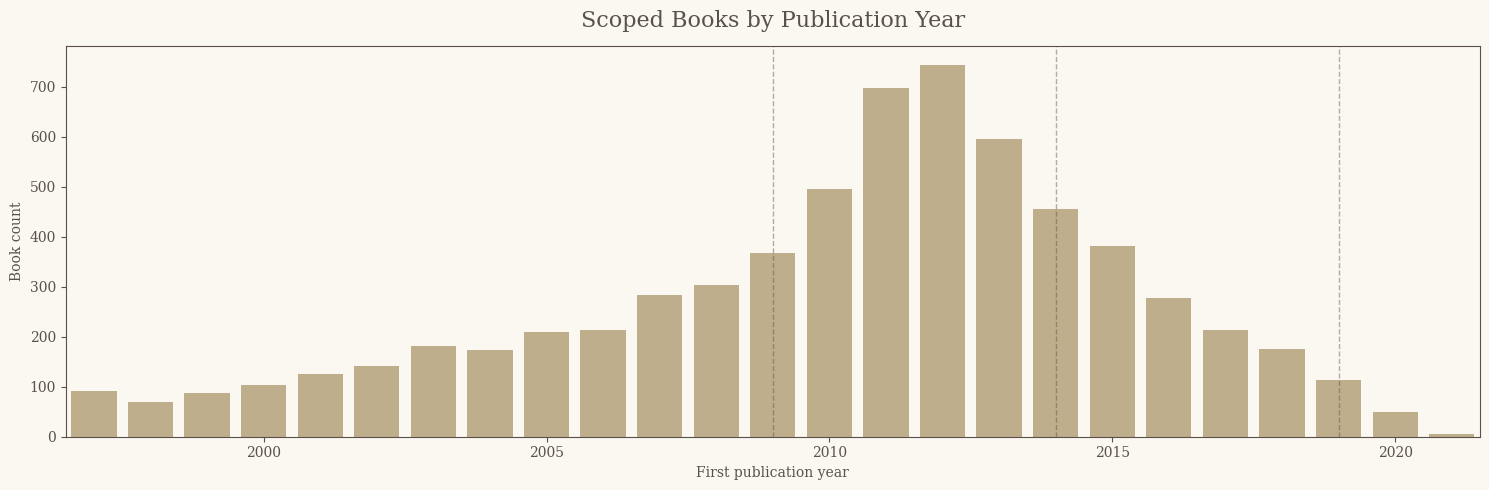

In [17]:
books_by_year = books.groupby("first_publish_year", as_index=False).agg(book_count=("bookId", "nunique"))
fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(books_by_year["first_publish_year"], books_by_year["book_count"], color=PALETTE[0], width=0.8)
for break_year in ERA_BREAKS:
    ax.axvline(break_year, color=TEXT_COLOR, linestyle="--", linewidth=1.0, alpha=0.45)
ax.set_title("Scoped Books by Publication Year", fontsize=16, pad=14)
ax.set_xlabel("First publication year")
ax.set_ylabel("Book count")
ax.set_xlim(1996.5, 2021.5)
plt.tight_layout()
savefig(fig, "06_books_by_year.png")
plt.show()

books_by_year.to_csv(TABLE_DIR / "books_by_year_report.csv", index=False)